In [1]:
import os

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import gc
import torch
import torch.nn as nn
import pandas as pd
import numpy as np

from datasets import Dataset

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.utils.class_weight import compute_class_weight

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [2]:
import shutil

shutil.rmtree('/content/drive', ignore_errors=True)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os

os.listdir('/content/drive/MyDrive/ABSA_DATASET')

['university_balanced-new.csv',
 'teacher_balanced-new.csv',
 'course_balanced-new.csv',
 'university_test.csv']

In [4]:
import os

os.makedirs(
    "/content/drive/MyDrive/ABSA_DATASET/predictions",
    exist_ok=True
)

os.makedirs(
    "/content/drive/MyDrive/ABSA_DATASET/results",
    exist_ok=True
)

os.makedirs(
    "/content/drive/MyDrive/ABSA_DATASET/models",
    exist_ok=True
)

os.makedirs(
    "/content/drive/MyDrive/ABSA_DATASET/training_history",
    exist_ok=True
)

In [5]:
course_balanced = pd.read_csv(
    "/content/drive/MyDrive/ABSA_DATASET/course_balanced-new.csv"
)

teacher_balanced = pd.read_csv(
    "/content/drive/MyDrive/ABSA_DATASET/teacher_balanced-new.csv"
)

university_test = pd.read_csv(
    "/content/drive/MyDrive/ABSA_DATASET/university_test.csv"
)

In [6]:
train_df = pd.concat(
    [course_balanced, teacher_balanced]
).reset_index(drop=True)

test_df = university_test.reset_index(drop=True)

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (8436, 5)
Test: (844, 7)


In [7]:
def format_input(row):

    return (
        "[DOMAIN] " + row["domain"] +
        " [ASPECT] " + row["aspect"] +
        " [TEXT] " + row["review"]
    )

train_df["input_text"] = train_df.apply(
    format_input,
    axis=1
)

test_df["input_text"] = test_df.apply(
    format_input,
    axis=1
)

In [8]:
label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

train_df["label"] = train_df["sentiment"].map(label_map)

test_df["label"] = test_df["sentiment"].map(label_map)

In [9]:
# =====================================================
# TRAIN / VALIDATION SPLIT
# =====================================================

train_df, val_df = train_test_split(
    train_df,
    test_size=0.1111,
    stratify=train_df["label"],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

# FIXED SHARED TEST SET
test_df = test_df.reset_index(drop=True)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (7498, 7)
Validation: (938, 7)
Test: (844, 7)


In [10]:
model_name = "answerdotai/ModernBERT-base"

tokenizer = AutoTokenizer.from_pretrained(
    model_name
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [11]:
train_dataset = Dataset.from_pandas(
    train_df[["input_text", "label"]]
)

val_dataset = Dataset.from_pandas(
    val_df[["input_text", "label"]]
)

test_dataset = Dataset.from_pandas(
    test_df[["input_text", "label"]]
)

In [12]:
def tokenize_function(examples):

    return tokenizer(
        examples["input_text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

val_dataset = val_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/7498 [00:00<?, ? examples/s]

Map:   0%|          | 0/938 [00:00<?, ? examples/s]

Map:   0%|          | 0/844 [00:00<?, ? examples/s]

In [13]:
train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

val_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

In [14]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    preds = np.argmax(logits, axis=1)

    return {

        "accuracy": accuracy_score(
            labels,
            preds
        ),

        "f1_macro": f1_score(
            labels,
            preds,
            average="macro"
        ),

        "f1_weighted": f1_score(
            labels,
            preds,
            average="weighted"
        )
    }

In [15]:
def run_experiment(

    experiment_name,
    learning_rate=2e-5,
    epochs=5,
    use_class_weights=True
):

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=3
    )

    if use_class_weights:

        labels = train_df["label"].values

        class_weights = compute_class_weight(
            class_weight="balanced",
            classes=np.unique(labels),
            y=labels
        )

        class_weights_tensor = torch.tensor(
            class_weights,
            dtype=torch.float
        )

        class WeightedTrainer(Trainer):

            def compute_loss(
                self,
                model,
                inputs,
                return_outputs=False,
                **kwargs
            ):

                labels = inputs.get("labels")

                outputs = model(**inputs)

                logits = outputs.get("logits")

                loss_fct = nn.CrossEntropyLoss(
                    weight=class_weights_tensor.to(model.device)
                )

                loss = loss_fct(logits, labels)

                return (loss, outputs) if return_outputs else loss

        trainer_class = WeightedTrainer

    else:

        trainer_class = Trainer

    training_args = TrainingArguments(

        output_dir=f"./{experiment_name}",

        eval_strategy="epoch",

        save_strategy="no",

        learning_rate=learning_rate,

        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,

        num_train_epochs=epochs,

        weight_decay=0.01,

        logging_steps=100,

        fp16=True,

        report_to="none"
    )

    trainer = trainer_class(

        model=model,

        args=training_args,

        train_dataset=train_dataset,
        eval_dataset=val_dataset,

        compute_metrics=compute_metrics
    )

    trainer.train()

    test_results = trainer.evaluate(
        test_dataset
    )

    print(test_results)

    predictions = trainer.predict(
        test_dataset
    )

    y_pred = np.argmax(
        predictions.predictions,
        axis=1
    )

    y_true = predictions.label_ids


    # =====================================================
    # CLASSIFICATION REPORT
    # =====================================================

    report_dict = classification_report(

        y_true,
        y_pred,

        target_names=[
            "negative",
            "neutral",
            "positive"
        ],

        output_dict=True
    )

    report_df = pd.DataFrame(
        report_dict
    ).transpose()

    report_df.to_csv(

        f"/content/drive/MyDrive/ABSA_DATASET/results/{experiment_name}_classification_report.csv"
    )

    print(report_df)

    # =====================================================
    # CONFUSION MATRIX
    # =====================================================

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    cm_df = pd.DataFrame(

        cm,

        index=[
            "Actual Negative",
            "Actual Neutral",
            "Actual Positive"
        ],

        columns=[
            "Pred Negative",
            "Pred Neutral",
            "Pred Positive"
        ]
    )

    cm_df.to_csv(

        f"/content/drive/MyDrive/ABSA_DATASET/results/{experiment_name}_confusion_matrix.csv"
    )

    print(cm_df)

    # =====================================================
    # TRAINING HISTORY
    # =====================================================

    history = trainer.state.log_history

    history_df = pd.DataFrame(history)

    history_df.to_csv(

        f"/content/drive/MyDrive/ABSA_DATASET/results/{experiment_name}_training_history.csv",

        index=False
    )

    print(history_df.head())



    # =====================================================
    # FINAL PREDICTIONS
    # =====================================================

    label_reverse_map = {

        0: "negative",
        1: "neutral",
        2: "positive"
    }

    final_predictions_df = test_df.copy()

    final_predictions_df["true_label"] = y_true

    final_predictions_df["predicted_label"] = y_pred

    final_predictions_df["true_sentiment"] = (

        final_predictions_df["true_label"]
        .map(label_reverse_map)
    )

    final_predictions_df["predicted_sentiment"] = (

        final_predictions_df["predicted_label"]
        .map(label_reverse_map)
    )

    final_predictions_df.to_csv(

        f"/content/drive/MyDrive/ABSA_DATASET/predictions/{experiment_name}_predictions.csv",

        index=False
    )

    print(final_predictions_df.head())

    # ERROR ANALYSIS
    errors_df = final_predictions_df[

        final_predictions_df["true_label"]
        != final_predictions_df["predicted_label"]
    ]

    errors_df.to_csv(
        f"/content/drive/MyDrive/ABSA_DATASET/results/{experiment_name}_errors.csv",
        index=False
    )

    print("Total Errors:", len(errors_df))

    # NEUTRAL ERROR
    neutral_errors = errors_df[

        errors_df["true_sentiment"]
        == "neutral"
    ]

    neutral_errors.to_csv(
        f"/content/drive/MyDrive/ABSA_DATASET/results/{experiment_name}_neutral_errors.csv",
        index=False
    )

    print("Neutral Errors:", len(neutral_errors))

    # =====================================================
    # METRICS CSV
    # =====================================================

    metrics_df = pd.DataFrame({

        "Metric": [
            "Accuracy",
            "Macro_F1",
            "Weighted_F1"
        ],

        "Score": [

            test_results["eval_accuracy"],
            test_results["eval_f1_macro"],
            test_results["eval_f1_weighted"]
        ]
    })

    metrics_df.to_csv(

        f"/content/drive/MyDrive/ABSA_DATASET/results/{experiment_name}_metrics.csv",

        index=False
    )

    print(metrics_df)

    # =====================================================
    # SAVE MODEL
    # =====================================================

    trainer.save_model(

        f"/content/drive/MyDrive/ABSA_DATASET/models/{experiment_name}"
    )

    tokenizer.save_pretrained(

        f"/content/drive/MyDrive/ABSA_DATASET/models/{experiment_name}"
    )

    # =====================================================
    # CLEANUP
    # =====================================================

    trainer.optimizer = None
    trainer.lr_scheduler = None

    del model
    del trainer

    gc.collect()

    torch.cuda.empty_cache()

    torch.cuda.ipc_collect()

    return test_results

In [16]:
gc.collect()

torch.cuda.empty_cache()

torch.cuda.ipc_collect()

In [17]:
best_metrics = run_experiment(
    "course_teacher_to_university_best"
)

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.651175,0.585165,0.779318,0.725079,0.794948
2,0.457341,0.555497,0.799574,0.746063,0.811120
3,0.280349,0.884166,0.811301,0.746375,0.814507
4,0.176519,1.440968,0.814499,0.741863,0.813838
5,0.054444,1.532650,0.800640,0.729719,0.805382


{'eval_loss': 0.8975666761398315, 'eval_accuracy': 0.919431279620853, 'eval_f1_macro': 0.7023980415443195, 'eval_f1_weighted': 0.9205956265063513, 'eval_runtime': 3.1423, 'eval_samples_per_second': 268.59, 'eval_steps_per_second': 16.866, 'epoch': 5.0}
              precision    recall  f1-score     support
negative       0.853659  0.795455  0.823529  132.000000
neutral        0.292683  0.333333  0.311688   36.000000
positive       0.969118  0.974852  0.971976  676.000000
accuracy       0.919431  0.919431  0.919431    0.919431
macro avg      0.705153  0.701213  0.702398  844.000000
weighted avg   0.922207  0.919431  0.920596  844.000000
                 Pred Negative  Pred Neutral  Pred Positive
Actual Negative            105            16             11
Actual Neutral              14            12             10
Actual Positive              4            13            659
       loss  grad_norm  learning_rate     epoch  step  eval_loss  \
0  1.024918   4.366432       0.000019  0.213220

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [18]:
epoch4_metrics = run_experiment(
    "course_teacher_to_university_4epoch",
    epochs=4
)

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.686676,0.610350,0.799574,0.743454,0.808152
2,0.476572,0.549567,0.812367,0.760508,0.822912
3,0.273146,0.783941,0.830490,0.760327,0.831341
4,0.159958,1.053129,0.828358,0.760495,0.829625


{'eval_loss': 0.549283504486084, 'eval_accuracy': 0.9111374407582938, 'eval_f1_macro': 0.6959489680532095, 'eval_f1_weighted': 0.9161130112277504, 'eval_runtime': 3.143, 'eval_samples_per_second': 268.537, 'eval_steps_per_second': 16.863, 'epoch': 4.0}
              precision    recall  f1-score     support
negative       0.800000  0.818182  0.808989  132.000000
neutral        0.270833  0.361111  0.309524   36.000000
positive       0.980333  0.958580  0.969334  676.000000
accuracy       0.911137  0.911137  0.911137    0.911137
macro avg      0.683722  0.712624  0.695949  844.000000
weighted avg   0.921866  0.911137  0.916113  844.000000
                 Pred Negative  Pred Neutral  Pred Positive
Actual Negative            108            19              5
Actual Neutral              15            13              8
Actual Positive             12            16            648
       loss  grad_norm  learning_rate     epoch  step  eval_loss  \
0  1.081371   6.948673       0.000019  0.213220

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [19]:
lr1e5_metrics = run_experiment(
    "course_teacher_to_university_lr1e5",
    learning_rate=1e-5
)

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.722630,0.630427,0.763326,0.709917,0.778624
2,0.551788,0.581288,0.792111,0.739727,0.803974
3,0.357783,0.682372,0.804904,0.748494,0.812470
4,0.269206,0.914839,0.808102,0.736241,0.809280
5,0.138550,1.074599,0.811301,0.740483,0.813578


{'eval_loss': 0.5260564684867859, 'eval_accuracy': 0.9123222748815166, 'eval_f1_macro': 0.7141600253997403, 'eval_f1_weighted': 0.9172920357760248, 'eval_runtime': 3.1704, 'eval_samples_per_second': 266.214, 'eval_steps_per_second': 16.717, 'epoch': 5.0}
              precision    recall  f1-score     support
negative       0.814815  0.833333  0.823970  132.000000
neutral        0.306122  0.416667  0.352941   36.000000
positive       0.977273  0.954142  0.965569  676.000000
accuracy       0.912322  0.912322  0.912322    0.912322
macro avg      0.699403  0.734714  0.714160  844.000000
weighted avg   0.923237  0.912322  0.917292  844.000000
                 Pred Negative  Pred Neutral  Pred Positive
Actual Negative            110            15              7
Actual Neutral              13            15              8
Actual Positive             12            19            645
       loss  grad_norm  learning_rate     epoch  step  eval_loss  \
0  1.066459   6.148934       0.000010  0.2132

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [20]:
lr3e5_metrics = run_experiment(
    "course_teacher_to_university_lr3e5",
    learning_rate=3e-5
)

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.628810,0.569979,0.804904,0.744749,0.813393
2,0.459444,0.559893,0.824094,0.763932,0.826518
3,0.263266,0.888079,0.823028,0.762492,0.826102
4,0.161565,1.154474,0.816631,0.751703,0.818709
5,0.036860,1.474878,0.828358,0.767023,0.829452


{'eval_loss': 0.9220371842384338, 'eval_accuracy': 0.9087677725118484, 'eval_f1_macro': 0.6861016867933372, 'eval_f1_weighted': 0.9139711884670085, 'eval_runtime': 3.1397, 'eval_samples_per_second': 268.817, 'eval_steps_per_second': 16.881, 'epoch': 5.0}
              precision    recall  f1-score     support
negative       0.844961  0.825758  0.835249  132.000000
neutral        0.224490  0.305556  0.258824   36.000000
positive       0.971471  0.957101  0.964232  676.000000
accuracy       0.908768  0.908768  0.908768    0.908768
macro avg      0.680308  0.696138  0.686102  844.000000
weighted avg   0.919824  0.908768  0.913971  844.000000
                 Pred Negative  Pred Neutral  Pred Positive
Actual Negative            109            17              6
Actual Neutral              12            11             13
Actual Positive              8            21            647
       loss  grad_norm  learning_rate     epoch  step  eval_loss  \
0  1.070053   4.400013       0.000029  0.2132

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [21]:
no_weights_metrics = run_experiment(
    "course_teacher_to_university_no_weights",
    use_class_weights=False
)

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.529389,0.474279,0.814499,0.689752,0.793924
2,0.363132,0.455080,0.830490,0.743646,0.821298
3,0.215899,0.656222,0.840085,0.783000,0.841721
4,0.145480,0.906059,0.820896,0.748531,0.818888
5,0.035113,1.116178,0.816631,0.751003,0.822162


{'eval_loss': 0.46347668766975403, 'eval_accuracy': 0.9158767772511849, 'eval_f1_macro': 0.6834115278905983, 'eval_f1_weighted': 0.9183326356606545, 'eval_runtime': 3.1198, 'eval_samples_per_second': 270.533, 'eval_steps_per_second': 16.988, 'epoch': 5.0}
              precision    recall  f1-score     support
negative       0.824427  0.818182  0.821293  132.000000
neutral        0.238095  0.277778  0.256410   36.000000
positive       0.976155  0.968935  0.972532  676.000000
accuracy       0.915877  0.915877  0.915877    0.915877
macro avg      0.679559  0.688298  0.683412  844.000000
weighted avg   0.920944  0.915877  0.918333  844.000000
                 Pred Negative  Pred Neutral  Pred Positive
Actual Negative            108            20              4
Actual Neutral              14            10             12
Actual Positive              9            12            655
       loss  grad_norm  learning_rate     epoch  step  eval_loss  \
0  0.903153   9.506033       0.000019  0.213

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

             Experiment  Accuracy  Macro_F1  Weighted_F1
0  Weighted Loss (Best)  0.919431  0.702398     0.920596
1              4 Epochs  0.911137  0.695949     0.916113
2             LR = 1e-5  0.912322  0.714160     0.917292
3             LR = 3e-5  0.908768  0.686102     0.913971
4      No Weighted Loss  0.915877  0.683412     0.918333


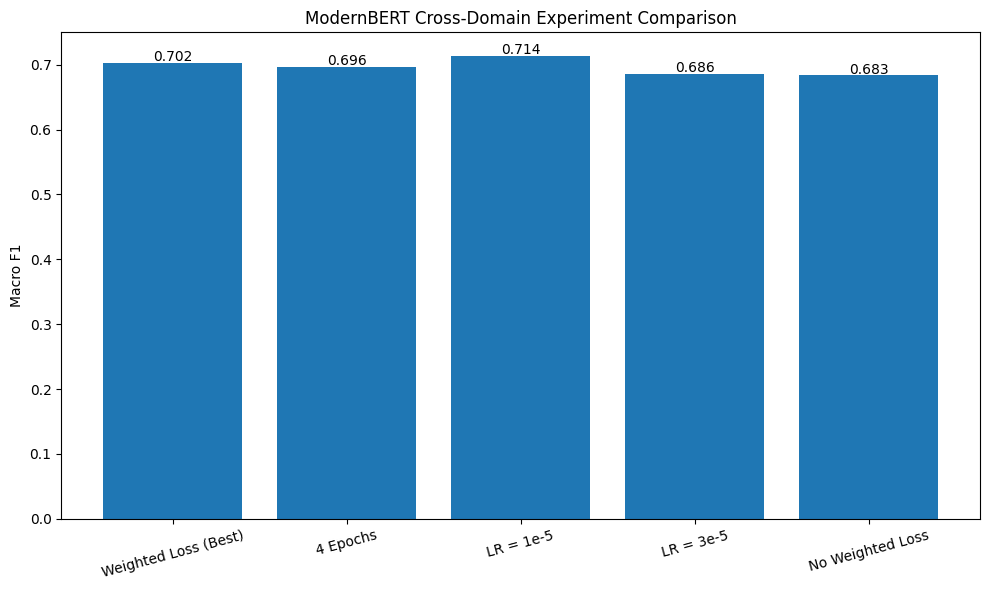

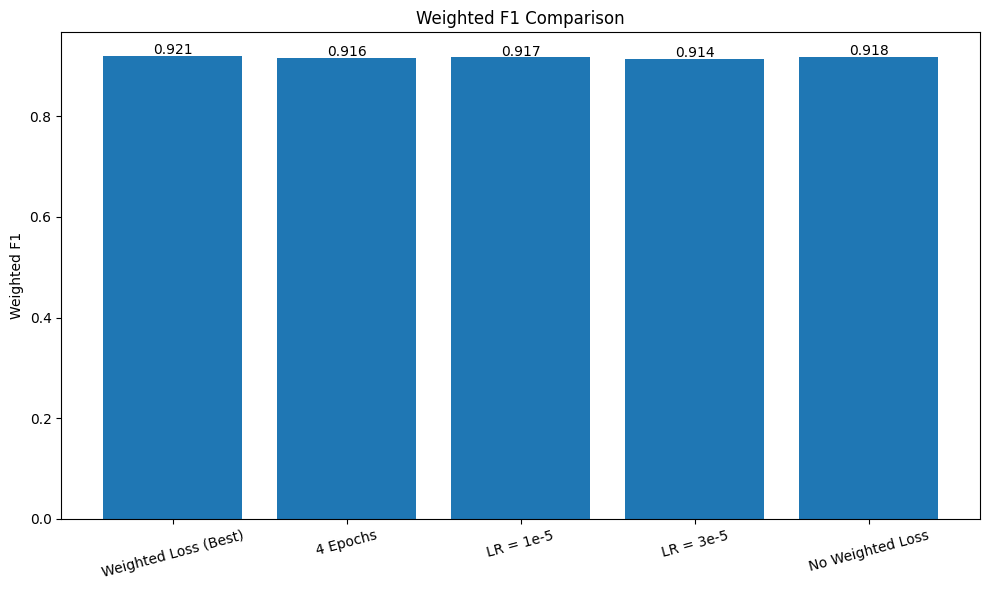

Plots saved successfully


In [22]:
import matplotlib.pyplot as plt

# =====================================================
# FINAL RESULTS TABLE
# =====================================================

final_results_df = pd.DataFrame({

    "Experiment": [

        "Weighted Loss (Best)",
        "4 Epochs",
        "LR = 1e-5",
        "LR = 3e-5",
        "No Weighted Loss"
    ],

    "Accuracy": [

        best_metrics["eval_accuracy"],
        epoch4_metrics["eval_accuracy"],
        lr1e5_metrics["eval_accuracy"],
        lr3e5_metrics["eval_accuracy"],
        no_weights_metrics["eval_accuracy"]
    ],

    "Macro_F1": [

        best_metrics["eval_f1_macro"],
        epoch4_metrics["eval_f1_macro"],
        lr1e5_metrics["eval_f1_macro"],
        lr3e5_metrics["eval_f1_macro"],
        no_weights_metrics["eval_f1_macro"]
    ],

    "Weighted_F1": [

        best_metrics["eval_f1_weighted"],
        epoch4_metrics["eval_f1_weighted"],
        lr1e5_metrics["eval_f1_weighted"],
        lr3e5_metrics["eval_f1_weighted"],
        no_weights_metrics["eval_f1_weighted"]
    ]
})

print(final_results_df)

# =====================================================
# SAVE FINAL RESULTS
# =====================================================

final_results_df.to_csv(

    "/content/drive/MyDrive/ABSA_DATASET/results/course_teacher_to_university_final_results.csv",

    index=False
)

# =====================================================
# MACRO F1 COMPARISON PLOT
# =====================================================

plt.figure(figsize=(10,6))

bars = plt.bar(
    final_results_df["Experiment"],
    final_results_df["Macro_F1"]
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.003,
        f"{height:.3f}",
        ha='center',
        fontsize=10
    )

plt.xticks(rotation=15)

plt.ylabel("Macro F1")

plt.title("ModernBERT Cross-Domain Experiment Comparison")

plt.tight_layout()

plt.savefig(

    "/content/drive/MyDrive/ABSA_DATASET/results/course_teacher_to_university_macrof1.png",

    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =====================================================
# WEIGHTED F1 COMPARISON PLOT
# =====================================================

plt.figure(figsize=(10,6))

bars = plt.bar(
    final_results_df["Experiment"],
    final_results_df["Weighted_F1"]
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.003,
        f"{height:.3f}",
        ha='center',
        fontsize=10
    )

plt.xticks(rotation=15)

plt.ylabel("Weighted F1")

plt.title("Weighted F1 Comparison")

plt.tight_layout()

plt.savefig(

    "/content/drive/MyDrive/ABSA_DATASET/results/course_teacher_to_university_weightedf1.png",

    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Plots saved successfully")